#### ***01 — Preprocessing***

Build the daily univariate target series for the chosen station, add the exogenous variables that will be used by SARIMAX and the LSTM (temperature, precipitation, day-of-week, weekend flag, US-federal-holiday flag, month), and split into train / test.

Output: `../data/processed_daily.csv` — one row per day, ready for every downstream notebook.

#### ***Imports***

In [1]:
import json
import ssl
import urllib.parse
import urllib.request

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot defaults
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

#### ***Load the raw CSV and filter to the target station***

In [2]:
# Raw session-level dataset (UTF-8 BOM, so we read with utf-8-sig)
CSV_PATH       = '../data/Electric_Vehicle_Charging_Station_Data.csv'
TARGET_STATION = 'BOULDER / N BOULDER REC 1'   # Highest-volume station (see notebook 00)

df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# Parse the session start timestamp and keep only the calendar date
df['Start_Date___Time'] = pd.to_datetime(df['Start_Date___Time'], errors='coerce')
df['date']              = df['Start_Date___Time'].dt.normalize()

# Subset to the target station only
df = df[df['Station_Name'] == TARGET_STATION].copy()
print(f'Sessions at target station: {len(df)}')

Sessions at target station: 16278


#### ***Daily aggregation***

In [3]:
# Sum of energy delivered per day (kWh)
daily = (df
         .groupby('date')['Energy__kWh_']
         .sum()
         .rename('energy_kwh'))

# Reindex over the full daily range to make missing days explicit
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
daily    = daily.reindex(full_idx).rename_axis('date')

# Days with no sessions are zero-demand days
daily = daily.fillna(0.0).to_frame()

print(f'Daily observations: {len(daily)}')
print(f'Date range:         {daily.index.min().date()} -> {daily.index.max().date()}')
daily.head()

Daily observations: 1927
Date range:         2018-08-22 -> 2023-11-30


,energy_kwh
date,
2018-08-22,29.816
2018-08-23,9.474
2018-08-24,29.668
2018-08-25,0.000
2018-08-26,47.488


#### ***Calendar features***

Integer day-of-week, weekend flag, and month. These are the exogenous variables used by SARIMAX and the LSTM later on.

In [4]:
# 0 = Monday, 6 = Sunday
daily['day_of_week'] = daily.index.dayofweek
daily['is_weekend']  = (daily['day_of_week'] >= 5).astype(int)
daily['month']       = daily.index.month
daily.head()

,energy_kwh,day_of_week,is_weekend,month
date,,,,
2018-08-22,29.816,2,0,8
2018-08-23,9.474,3,0,8
2018-08-24,29.668,4,0,8
2018-08-25,0.000,5,1,8
2018-08-26,47.488,6,1,8


#### ***US federal holidays***

Helper that returns the set of US federal holidays for any list of years (fixed-date holidays + nth-weekday-of-month rules). Juneteenth is included from 2021 onwards.

In [5]:
def _nth_weekday(year, month, weekday, n):
    """n-th occurrence of `weekday` (0=Mon..6=Sun) in the given month/year."""
    first  = pd.Timestamp(year=year, month=month, day=1)
    offset = (weekday - first.weekday()) % 7
    return first + pd.Timedelta(days=offset + 7 * (n - 1))

def _last_weekday(year, month, weekday):
    """Last occurrence of `weekday` in the given month/year."""
    if month == 12:
        next_first = pd.Timestamp(year=year + 1, month=1, day=1)
    else:
        next_first = pd.Timestamp(year=year, month=month + 1, day=1)
    last_day = next_first - pd.Timedelta(days=1)
    offset   = (last_day.weekday() - weekday) % 7
    return last_day - pd.Timedelta(days=offset)

def us_federal_holidays(years):
    """Return the set of US federal holidays for the given iterable of years."""
    out = set()
    for y in years:
        # Fixed-date holidays
        out.add(pd.Timestamp(year=y, month=1,  day=1))   # New Year's Day
        out.add(pd.Timestamp(year=y, month=7,  day=4))   # Independence Day
        out.add(pd.Timestamp(year=y, month=11, day=11))  # Veterans Day
        out.add(pd.Timestamp(year=y, month=12, day=25))  # Christmas
        if y >= 2021:
            out.add(pd.Timestamp(year=y, month=6, day=19))  # Juneteenth (federal since 2021)
        # Variable-date holidays
        out.add(_nth_weekday(y, 1,  0, 3))   # MLK Day        — 3rd Monday of January
        out.add(_nth_weekday(y, 2,  0, 3))   # Presidents Day — 3rd Monday of February
        out.add(_last_weekday(y, 5, 0))      # Memorial Day   — last Monday of May
        out.add(_nth_weekday(y, 9,  0, 1))   # Labor Day      — 1st Monday of September
        out.add(_nth_weekday(y, 10, 0, 2))   # Columbus Day   — 2nd Monday of October
        out.add(_nth_weekday(y, 11, 3, 4))   # Thanksgiving   — 4th Thursday of November
    return out

years_in_data = range(daily.index.min().year, daily.index.max().year + 1)
holidays      = us_federal_holidays(years_in_data)

daily['is_holiday'] = daily.index.isin(holidays).astype(int)
print(f'Total holiday-days in series: {int(daily["is_holiday"].sum())}')

Total holiday-days in series: 57


#### ***Weather data — Open-Meteo Historical API***

Daily temperature (mean / max / min) and precipitation for Boulder, fetched from the free **Open-Meteo Historical Weather API** (no API key needed). Request uses Python's standard-library `urllib` to avoid extra dependencies.

In [6]:
# Boulder, CO coordinates
LAT, LON = 40.0150, -105.2705

start_date = daily.index.min().strftime('%Y-%m-%d')
end_date   = daily.index.max().strftime('%Y-%m-%d')

params = {
    'latitude':   LAT,
    'longitude':  LON,
    'start_date': start_date,
    'end_date':   end_date,
    'daily':      'temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum',
    'timezone':   'America/Denver',
}
url = 'https://archive-api.open-meteo.com/v1/archive?' + urllib.parse.urlencode(params)

# One HTTP GET, parse the JSON response (certifi gives us a valid CA bundle on macOS)
ssl_ctx = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(url, timeout=60, context=ssl_ctx) as response:
    payload = json.loads(response.read().decode('utf-8'))

weather = pd.DataFrame(payload['daily'])
weather['time'] = pd.to_datetime(weather['time'])
weather = weather.set_index('time').rename_axis('date')
weather = weather.rename(columns={
    'temperature_2m_mean': 'temp_mean',
    'temperature_2m_max':  'temp_max',
    'temperature_2m_min':  'temp_min',
    'precipitation_sum':   'precipitation',
})

print(f'Weather rows: {len(weather)}')
weather.head()

Weather rows: 1927


,temp_mean,temp_max,temp_min,precipitation
date,,,,
2018-08-22,17.3,23.4,12.1,0.9
2018-08-23,21.7,29.0,15.1,0.4
2018-08-24,21.1,28.8,11.9,0.0
2018-08-25,21.4,29.4,12.9,0.8
2018-08-26,23.6,30.1,16.2,0.0


#### ***Merge features and sanity check***

In [7]:
# Join the weather frame onto the daily target series
data = daily.join(weather, how='left')

# Any weather gaps? (Should be zero given the API covers the full range.)
print(f'Missing temperature rows: {int(data["temp_mean"].isna().sum())}')
print(f'Missing precipitation rows: {int(data["precipitation"].isna().sum())}')

# Forward-fill any rare gaps as a safety net
data = data.ffill().bfill()
data.head()

Missing temperature rows: 0
Missing precipitation rows: 0


,energy_kwh,day_of_week,is_weekend,month,is_holiday,temp_mean,temp_max,temp_min,precipitation
date,,,,,,,,,
2018-08-22,29.816,2,0,8,0,17.3,23.4,12.1,0.9
2018-08-23,9.474,3,0,8,0,21.7,29.0,15.1,0.4
2018-08-24,29.668,4,0,8,0,21.1,28.8,11.9,0.0
2018-08-25,0.000,5,1,8,0,21.4,29.4,12.9,0.8
2018-08-26,47.488,6,1,8,0,23.6,30.1,16.2,0.0


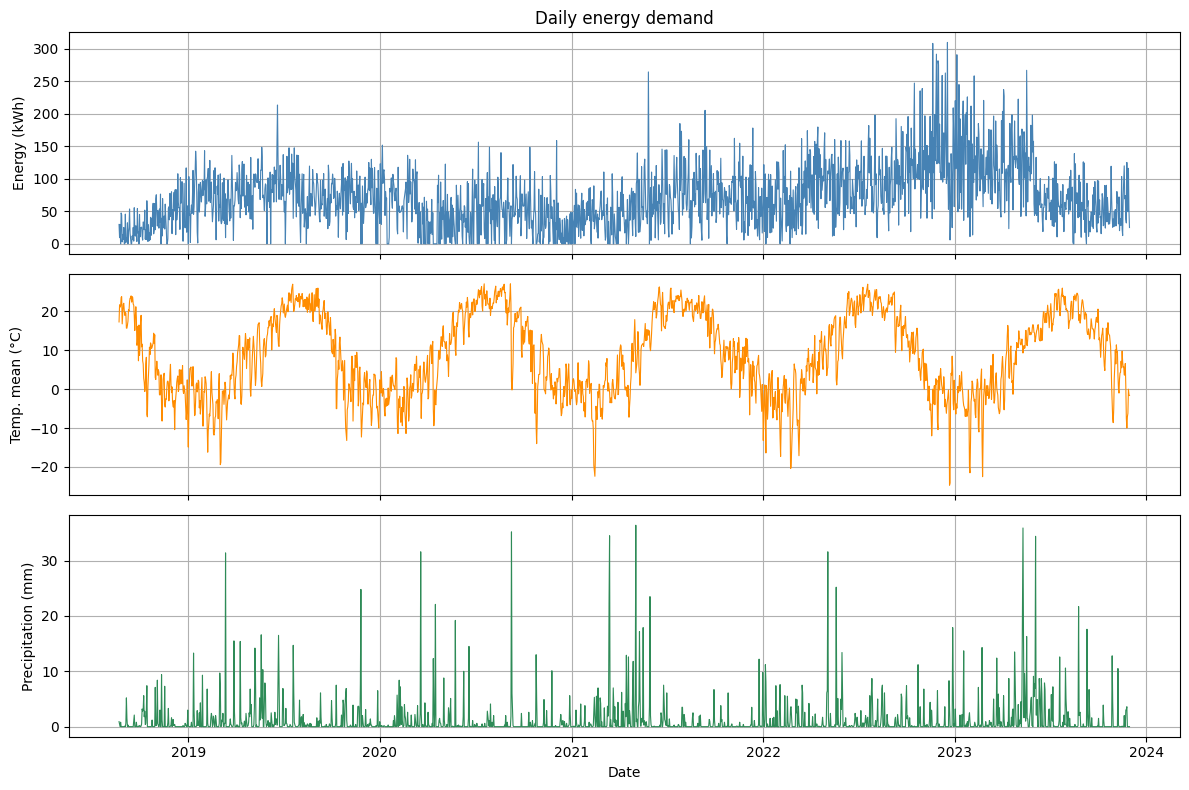

In [8]:
# Quick visual of the target and the main exogenous variables
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(12, 8))

axes[0].plot(data.index, data['energy_kwh'], color='steelblue', lw=0.8)
axes[0].set_ylabel('Energy (kWh)')
axes[0].set_title('Daily energy demand')

axes[1].plot(data.index, data['temp_mean'], color='darkorange', lw=0.8)
axes[1].set_ylabel('Temp. mean (°C)')

axes[2].plot(data.index, data['precipitation'], color='seagreen', lw=0.8)
axes[2].set_ylabel('Precipitation (mm)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

#### ***Train / test split***

Holdout = **last 30 days** of the series. With a 7-day-ahead forecasting horizon this gives roughly four non-overlapping evaluation weeks, which is more robust than evaluating a single 7-day window.

In [9]:
TEST_DAYS = 30
HORIZON   = 7

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train = data.loc[data.index <  split_date].copy()
test  = data.loc[data.index >= split_date].copy()

print(f'Split date:    {split_date.date()}')
print(f'Train period:  {train.index.min().date()} -> {train.index.max().date()} ({len(train)} days)')
print(f'Test  period:  {test.index.min().date()}  -> {test.index.max().date()} ({len(test)} days)')

Split date:    2023-11-01
Train period:  2018-08-22 -> 2023-10-31 (1897 days)
Test  period:  2023-11-01  -> 2023-11-30 (30 days)


#### ***Save processed data***

Everything downstream (`02`–`06`) reads from this single CSV — guaranteed identical inputs across models.

In [10]:
OUT_PATH = '../data/processed_daily.csv'
data.to_csv(OUT_PATH)

print(f'Saved: {OUT_PATH}')
print(f'Shape: {data.shape}')
data.tail()

Saved: ../data/processed_daily.csv
Shape: (1927, 9)


,energy_kwh,day_of_week,is_weekend,month,is_holiday,temp_mean,temp_max,temp_min,precipitation
date,,,,,,,,,
2023-11-26,56.289,6,1,11,0,-7.1,-0.7,-10.6,0.0
2023-11-27,49.445,0,0,11,0,-6.2,2.6,-11.4,0.0
2023-11-28,116.204,1,0,11,0,-0.0,9.4,-6.2,0.0
2023-11-29,52.223,2,0,11,0,-1.4,8.8,-7.2,0.0
2023-11-30,25.072,3,0,11,0,-1.6,1.1,-5.3,0.0


#### ***Summary***

- Daily target series at `BOULDER / N BOULDER REC 1`: **1,927 observations**, 2018-08-22 → 2023-11-30.
- Exogenous variables: `temp_mean`, `temp_max`, `temp_min`, `precipitation`, `day_of_week`, `is_weekend`, `is_holiday`, `month`.
- Train / test split: last **30 days** held out, 7-day forecast horizon.
- Processed file persisted to `../data/processed_daily.csv`.

**Next:** `02_stationarity.ipynb` — ADF tests, differencing, ACF / PACF on the training series to choose the SARIMA order.